# 1. Libraries and settings

In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import math
import datetime

import lightgbm as lgb
import optuna.integration.lightgbm as lgbo

from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error # 平均絶対誤差
from sklearn.metrics import mean_squared_error # 平均二乗誤差
from sklearn.metrics import mean_squared_log_error # 対数平均二乗誤差
from sklearn.metrics import r2_score # 決定係数
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import auc
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import missingno as msno
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Pandas setting to display more dataset rows and columns
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 600)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

# 2. Import data

In [3]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')
sample_submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,A/5 21171,7.25000,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00000,1,0,PC 17599,71.28330,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,STON/O2. 3101282,7.92500,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,113803,53.10000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00000,0,0,373450,8.05000,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.82920,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.00000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.00000,0,0,240276,9.68750,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.00000,0,0,315154,8.66250,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00000,1,1,3101298,12.28750,NaN,S


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [8]:
sample_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [9]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


# 3. Preprosessing

In [10]:
# Concat train and test
all_data = pd.concat([train, test], ignore_index=True)
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.00000,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,A/5 21171,7.25000,NaN,S
1,2,1.00000,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00000,1,0,PC 17599,71.28330,C85,C
2,3,1.00000,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,STON/O2. 3101282,7.92500,NaN,S
3,4,1.00000,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,113803,53.10000,C123,S
4,5,0.00000,3,"Allen, Mr. William Henry",male,35.00000,0,0,373450,8.05000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.05000,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.90000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.25000,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.05000,NaN,S


<AxesSubplot:>

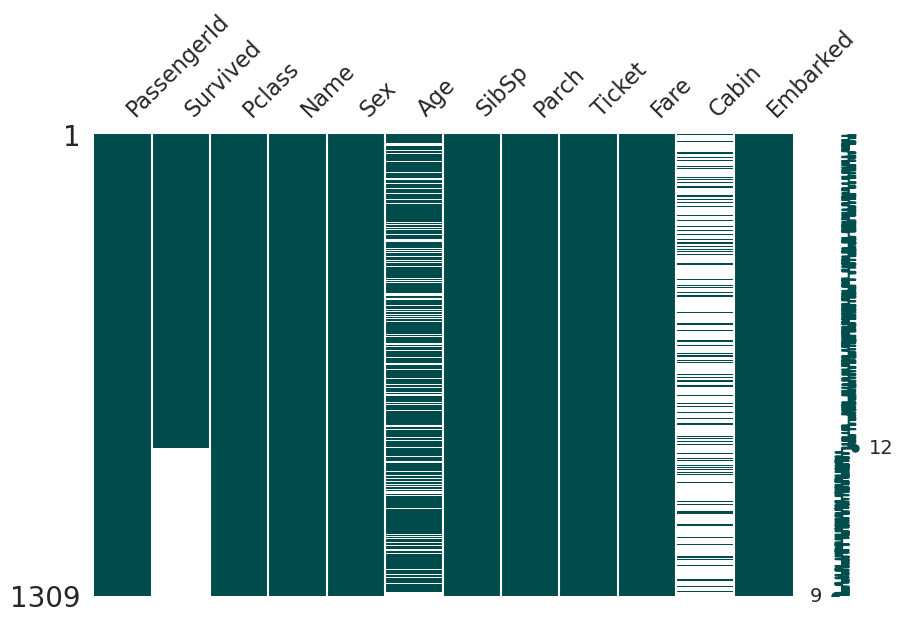

In [11]:
# 欠損値の有無を可視化します
# Search for missing data

msno.matrix(df=all_data, figsize=(10,6), color=(0,.3,.3))

*AgeとCabinに欠損値があるようです<br>
There seems to be missing values in "Age" and "Cabin"*

In [12]:
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.00000,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,A/5 21171,7.25000,NaN,S
1,2,1.00000,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00000,1,0,PC 17599,71.28330,C85,C
2,3,1.00000,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,STON/O2. 3101282,7.92500,NaN,S
3,4,1.00000,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,113803,53.10000,C123,S
4,5,0.00000,3,"Allen, Mr. William Henry",male,35.00000,0,0,373450,8.05000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.05000,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.90000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.25000,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.05000,NaN,S


In [13]:
# Replenish missing age data
# Classify by salutation and calculate the average value of each
# Nameの敬称で分類し、それぞれの平均年齢を算出
all_data_ary = [all_data]
for data in all_data_ary:
    data['Salutation'] = data.Name.str.extract(' ([A-Za-z]+).', expand=False)
for data in all_data_ary:
    data['Salutation'] = data['Salutation'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    data['Salutation'] = data['Salutation'].replace('Mlle', 'Miss')
    data['Salutation'] = data['Salutation'].replace('Ms', 'Miss')
    data['Salutation'] = data['Salutation'].replace('Mme', 'Mrs')

Salutation_mapping = {'Mr':1, 'Miss':2, 'Mrs':3, 'Master':4, 'Rare':5}
for data in all_data_ary:
    data['Salutation'] = data['Salutation'].map(Salutation_mapping)
    data['Salutation'] = data['Salutation'].fillna(0)

Age_Salutation_dn = data[['Age', 'Salutation']].dropna()

Age_Salutation_dn = np.array(Age_Salutation_dn)

t_age_Mr, t_age_Miss, t_age_Mrs, t_age_Master, t_age_Rare = 0, 0, 0, 0, 0
Mr_count, Miss_count, Mrs_count, Master_count, Rare_count = 0, 0, 0, 0, 0
for i in range(len(Age_Salutation_dn)):
    age = Age_Salutation_dn[i][0]
    if Age_Salutation_dn[i][1] == 1:
        t_age_Mr += age
        Mr_count += 1
    elif Age_Salutation_dn[i][1] == 2:
        t_age_Miss += age
        Miss_count += 1
    elif Age_Salutation_dn[i][1] == 3:
        t_age_Mrs += age
        Mrs_count += 1
    elif Age_Salutation_dn[i][1] == 4:
        t_age_Master += age
        Master_count += 1
    else:
        t_age_Rare += age
        Rare_count += 1

m_age_Mr = t_age_Mr / Mr_count
m_age_Miss = t_age_Miss / Miss_count
m_age_Mrs = t_age_Mrs / Mrs_count
m_age_Master = t_age_Master / Master_count
m_age_Rare = t_age_Rare / Rare_count

print('Mr:', m_age_Mr)
print('Miss:', m_age_Miss)
print('Mrs:', m_age_Mrs)
print('Master:', m_age_Master)
print('Rare:', m_age_Rare)

Mr: 32.28291814946619
Miss: 21.83535885167464
Mrs: 37.15151515151515
Master: 5.366923076923078
Rare: 36.89655172413793


In [14]:
all_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Salutation
0,1,0.00000,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,A/5 21171,7.25000,NaN,S,1.00000
1,2,1.00000,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.00000,1,0,PC 17599,71.28330,C85,C,3.00000
2,3,1.00000,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,STON/O2. 3101282,7.92500,NaN,S,2.00000
3,4,1.00000,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,113803,53.10000,C123,S,3.00000
4,5,0.00000,3,"Allen, Mr. William Henry",male,35.00000,0,0,373450,8.05000,NaN,S,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.05000,NaN,S,1.00000
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.90000,C105,C,0.00000
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.25000,NaN,S,1.00000
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.05000,NaN,S,1.00000


In [15]:
# すべてのデータを数値に置き換える
data_set = DataFrame(all_data.drop(['PassengerId', 'Name', 'Ticket'], axis=1)) # 使わない列を削除
data_set = data_set.fillna({'Fare':0, 'Cabin':0,'Embarked':0}) # 'Fare'と'Cabinと'Embarked'の空欄を0で埋める 
data_set = data_set.replace({'male':0, 'female':1, 'S':1, 'C':2, 'Q':3}) # 文字列を数値に置き換え(Sex, Embarked)
data_set = data_set.replace({'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7, 'T':8}, regex=True) # 文字列を含むデータを部分一致で数値に置き換え(Cabin)

# 年齢の欠損補充（Mr,Miss,Mrs,Master,Rare別に）
for i in range(len(data_set)):
    salutation = data_set['Salutation'][i]
    if salutation == 1:
        if pd.isnull(data_set['Age'][i]):
            data_set['Age'].loc[i] = m_age_Mr
    elif salutation == 2:
        if pd.isnull(data_set['Age'][i]):
            data_set['Age'].loc[i] = m_age_Miss
    elif salutation == 3:
        if pd.isnull(data_set['Age'][i]):
            data_set['Age'].loc[i] = m_age_Mrs
    elif salutation == 4:
        if pd.isnull(data_set['Age'][i]):
            data_set['Age'].loc[i] = m_age_Master
    else:
        if pd.isnull(data_set['Age'][i]):
            data_set['Age'].loc[i] = m_age_Rare

# 新たに項目を追加する
# 自分を含めた家族人数
data_set['FamilySize'] = data_set['SibSp'] + data_set['Parch'] + 1
# 一人かどうか、FamilySizeが2以上5未満、FamilySizeが5以上、Cabinが0かどうか
isAlone = []
#FamilySize_M = []
#FamilySize_L = []
isCabinNo = []
#roundAgeArray = []
#roundFareArray = []
for i in range(len(data_set)):
    if data_set['FamilySize'][i] == 1:
        isAlone.append(1)
    else:
        isAlone.append(0)
    if data_set['Cabin'][i] == 0:
        isCabinNo.append(1)
    else:
        isCabinNo.append(0)
#    if data_set['FamilySize'][i] < 2:
#        FamilySize_M.append(0)
#        FamilySize_L.append(0)
#    elif data_set['FamilySize'][i] < 5:
#        FamilySize_M.append(1)
#        FamilySize_L.append(0)
#    else:
#        FamilySize_M.append(0)
#        FamilySize_L.append(1)
    # 年代
 #   roundAge = int(data_set['Age'][i] / 10)
 #   roundAgeArray.append(roundAge)
    # 料金
 #   if data_set['Fare'][i] > 0:
 #       roundFare = int(math.log(data_set['Fare'][i]))
 #   else:
 #       roundFare = 0
 #   roundFareArray.append(roundFare)
#    print(roundFare)

data_set['isAlone'] = isAlone
#data_set['FamilySize_M'] = FamilySize_M
#data_set['FamilySize_L'] = FamilySize_L
data_set['isCabinNo'] = isCabinNo
#data_set['roundAge'] = roundAgeArray
#data_set['roundFare'] = roundFareArray

data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    float64
 1   Pclass      1309 non-null   int64  
 2   Sex         1309 non-null   int64  
 3   Age         1309 non-null   float64
 4   SibSp       1309 non-null   int64  
 5   Parch       1309 non-null   int64  
 6   Fare        1309 non-null   float64
 7   Cabin       1309 non-null   int64  
 8   Embarked    1309 non-null   int64  
 9   Salutation  1309 non-null   float64
 10  FamilySize  1309 non-null   int64  
 11  isAlone     1309 non-null   int64  
 12  isCabinNo   1309 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 133.1 KB


<AxesSubplot:>

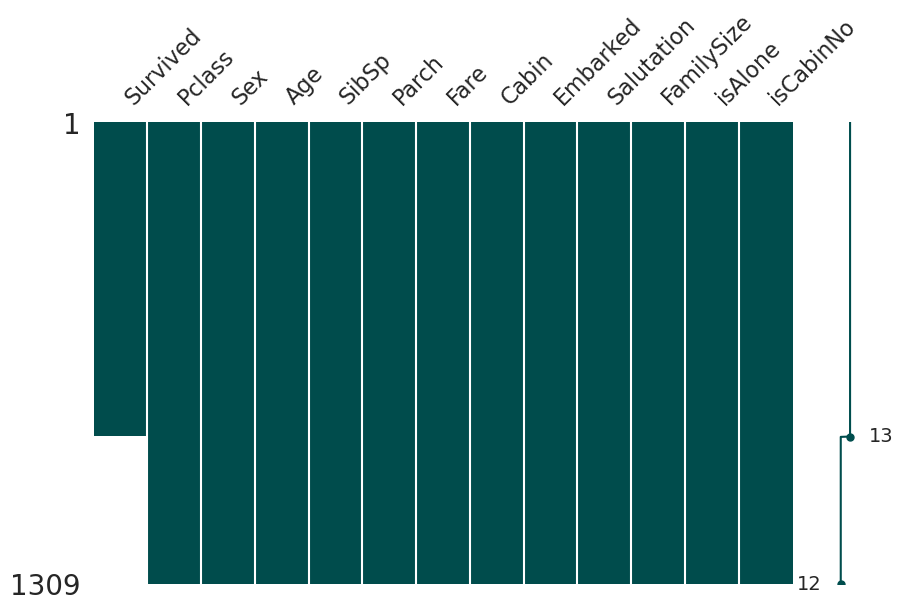

In [16]:
# もう一度欠損値の有無を可視化します
# Search for missing data

msno.matrix(df=data_set, figsize=(10,6), color=(0,.3,.3))

*欠損値はありません<br>
No missing value*

In [17]:
data_set.describe().T\
        .style.bar(subset=['mean'], color=px.colors.qualitative.G10[0])\
        .background_gradient(subset=['std'], cmap='Greens')\
        .background_gradient(subset=['50%'], cmap='BuGn')

,count,mean,std,min,25%,50%,75%,max
Survived,891.000000,0.383838,0.486592,0.000000,0.000000,0.000000,1.000000,1.000000
Pclass,1309.000000,2.294882,0.837836,1.000000,2.000000,3.000000,3.000000,3.000000
Sex,1309.000000,0.355997,0.478997,0.000000,0.000000,0.000000,1.000000,1.000000
Age,1309.000000,29.927232,13.180427,0.170000,21.835359,30.000000,36.000000,80.000000
SibSp,1309.000000,0.498854,1.041658,0.000000,0.000000,0.000000,1.000000,8.000000
Parch,1309.000000,0.385027,0.865560,0.000000,0.000000,0.000000,0.000000,9.000000
Fare,1309.000000,33.270043,51.747063,0.000000,7.895800,14.454200,31.275000,512.329200
Cabin,1309.000000,0.755539,1.557701,0.000000,0.000000,0.000000,0.000000,8.000000
Embarked,1309.000000,1.392666,0.655586,0.000000,1.000000,1.000000,2.000000,3.000000
Salutation,1309.000000,1.675325,1.034206,0.000000,1.000000,1.000000,2.000000,5.000000


In [18]:
feat_ary = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Cabin',
    'Embarked',
    'Salutation',
    'FamilySize',
    'isAlone',
#    'FamilySize_M',
#    'FamilySize_L',
    'isCabinNo'#,
#    'roundAge',
#    'roundFare'
]

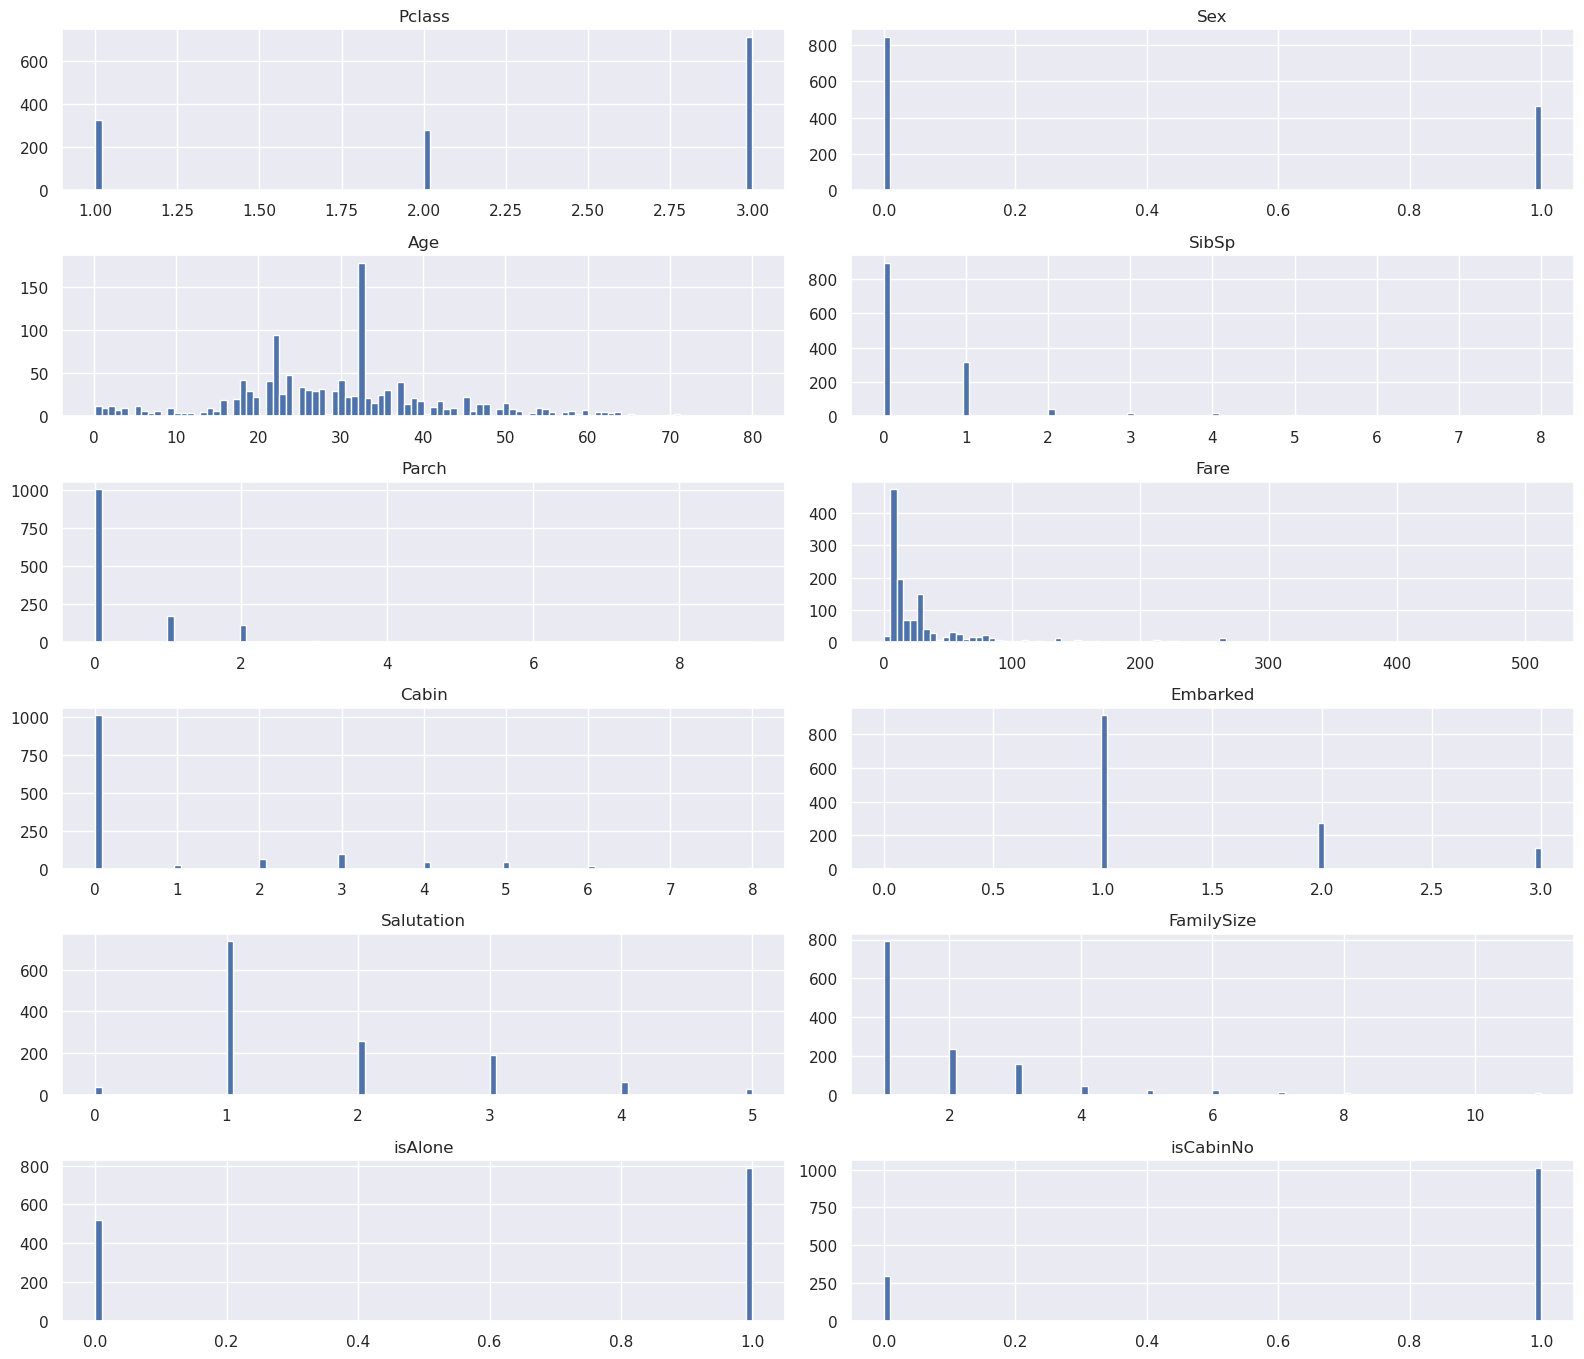

In [19]:
# 特徴量ごとの分布を可視化
# Visualization of distribution for each feature

figure = plt.figure(figsize=(16, 18))
count = 0
for i in range(len(feat_ary)):
    feat_name = feat_ary[i]
    plt.subplot(8, 2, count+1)
    plt.hist(data_set[feat_name], bins=100)
    plt.title(f'{feat_name}')
    count += 1
figure.tight_layout(h_pad=1.0, w_pad=0.8)
plt.show()

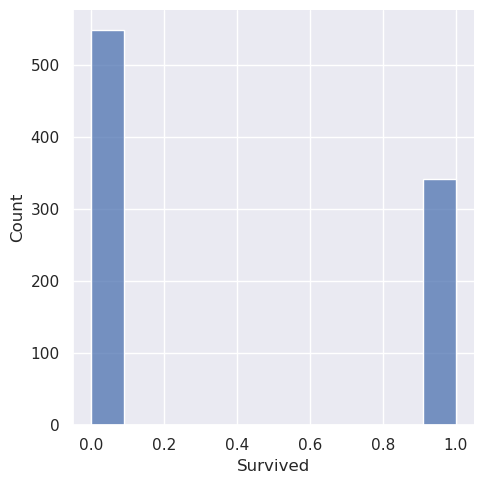

In [20]:
# Survivedの分布を可視化
# Histogram of 'Survived'

sns.displot(train['Survived'], height=5)
plt.show()

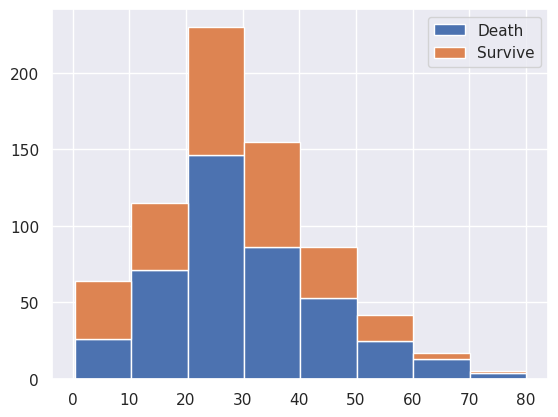

In [21]:
train_df = train.copy()
train_df
plt.hist((train_df[train_df["Survived"] == 0]["Age"].values, train_df[train_df["Survived"] == 1]["Age"].values), histtype = "barstacked", bins=8, label=("Death", "Survive"))
plt.legend()

In [22]:
data_set['Age'] = data_set['Age'] / 10
data_set['Fare'] = data_set['Fare'] / 100

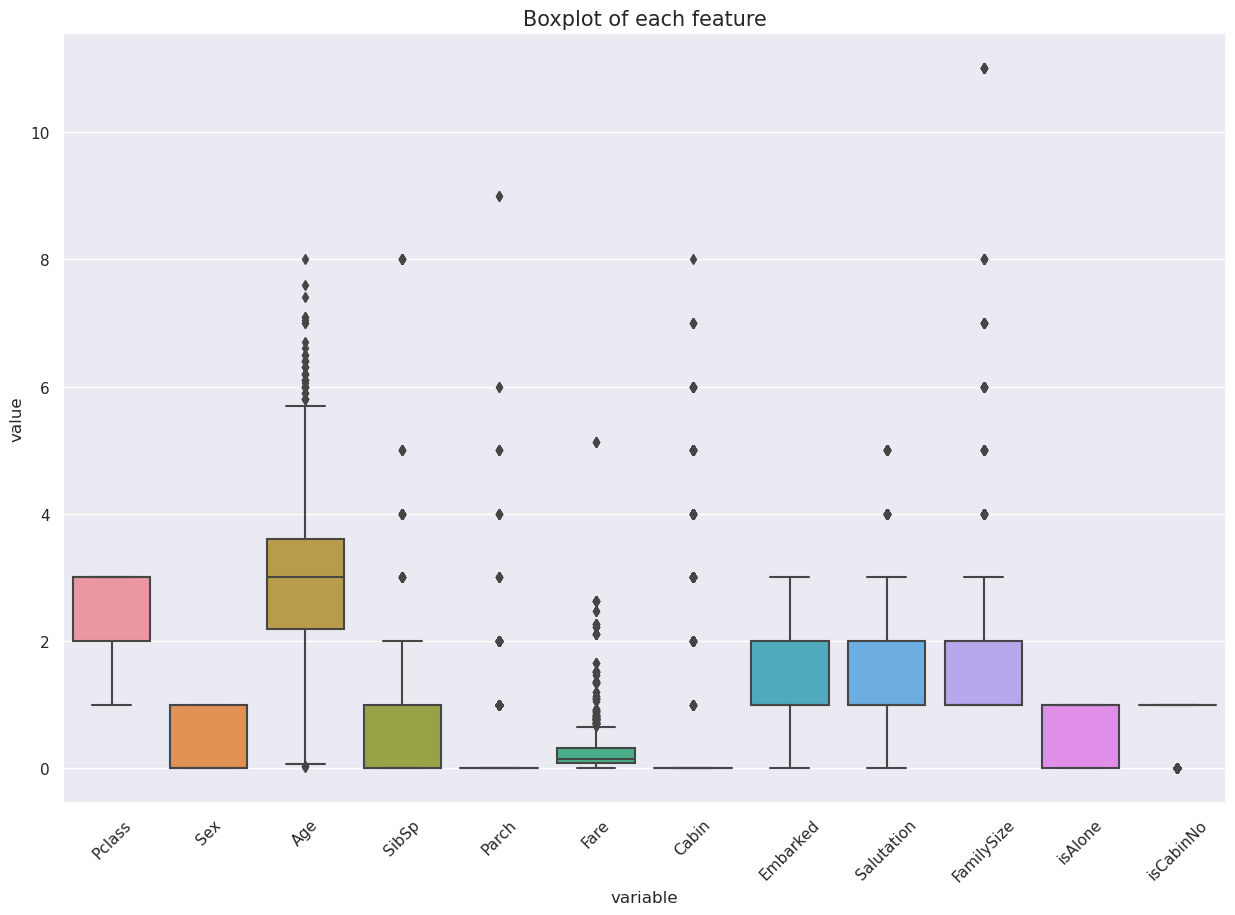

In [23]:
# Boxplot of each feature

df_all_data = pd.DataFrame(data = data_set, columns = feat_ary)
plt.figure(figsize=(15,10)) 
sns.boxplot(x="variable", y="value", data=pd.melt(df_all_data)).set_title('Boxplot of each feature',size=15)
plt.xticks(rotation=45)
plt.show()

In [24]:
# Split train and test

train = data_set.iloc[train.index[0]:train.index[-1]+1]
test = data_set.iloc[train.index[-1]+1:]

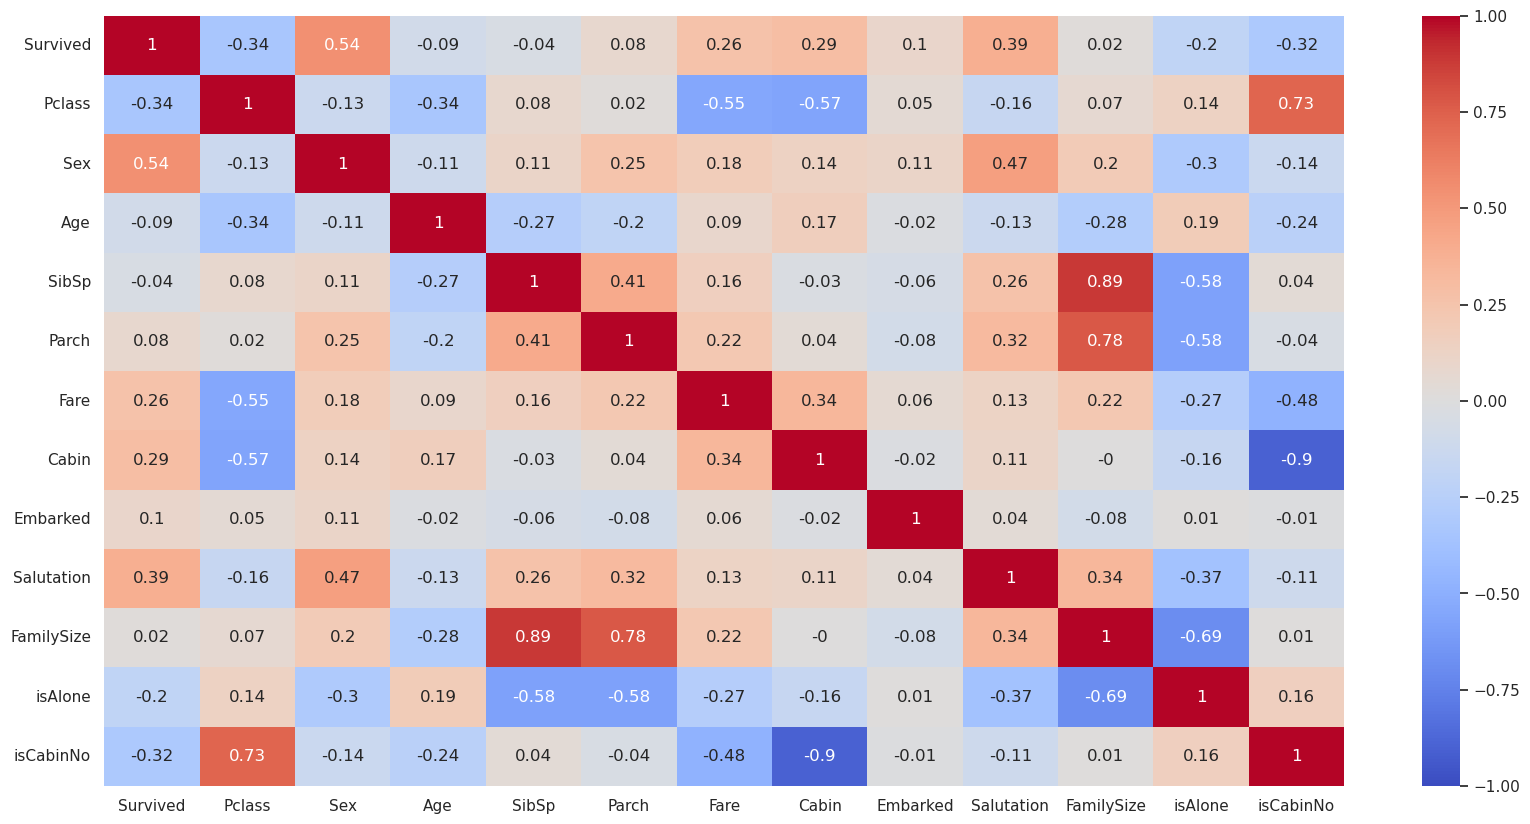

In [25]:
#Heatmap(train)

corr = train.corr().round(2)
plt.figure(figsize=(20,10))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, square=False, annot=True, cmap='coolwarm')
plt.show()

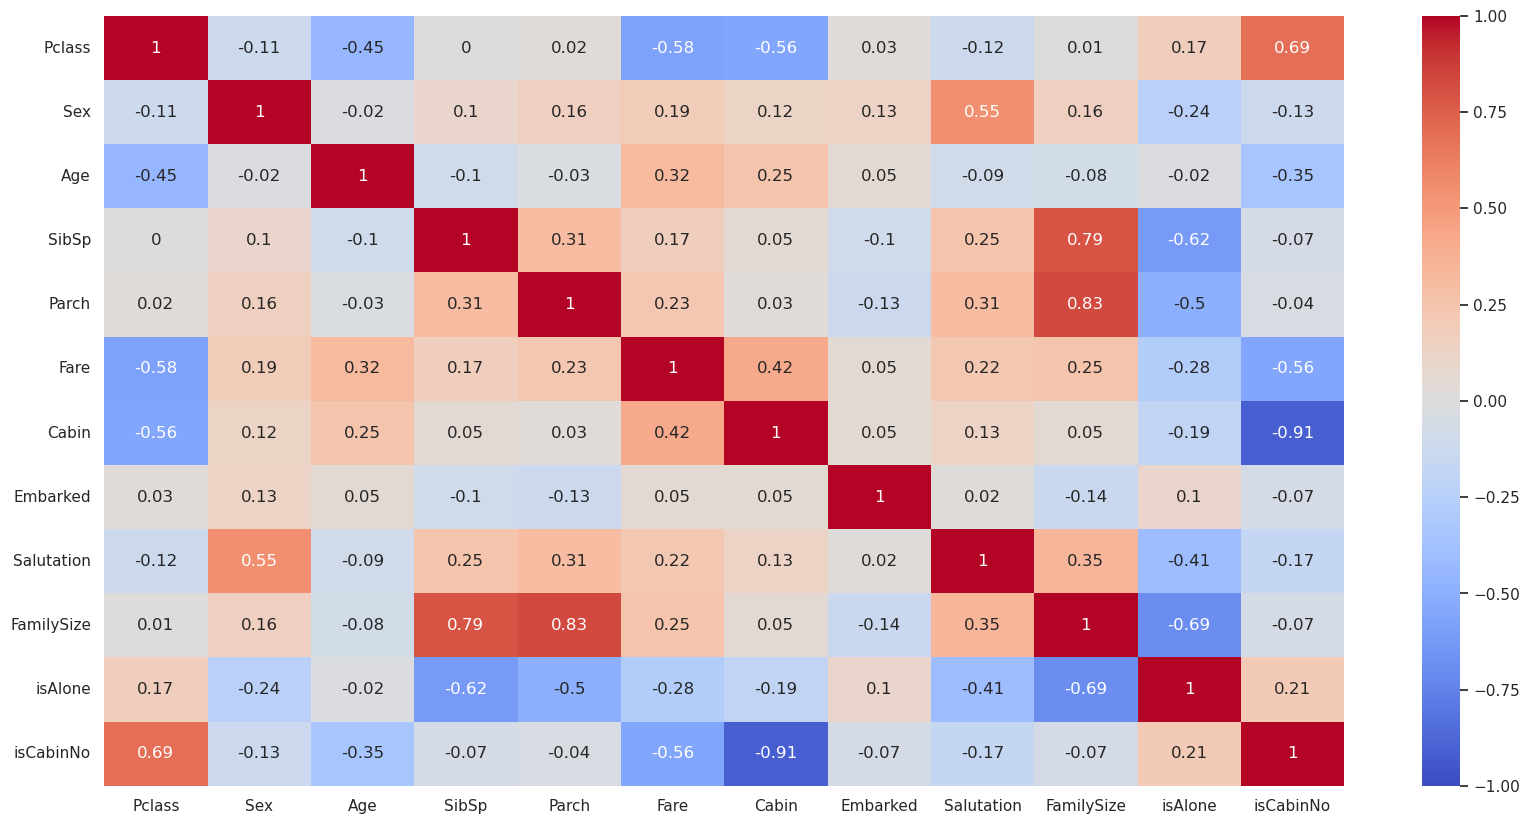

In [26]:
#Heatmap(test)

corr = test.drop(columns=['Survived']).corr().round(2)
plt.figure(figsize=(20,10))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, square=False, annot=True, cmap='coolwarm')
plt.show()

# 4. Modeling

In [27]:
X = train[feat_ary]
value = train['Survived']

In [28]:
# optunaを使うか使わないかを指定
# optuna switch(Using optuna or not)
optuna_switch = 'off' # 'on' or other

# GPUを使うかどうかを指定（使うときはACCELERATORを指定する）
# usingGPU(Using GPU or not)
usingGPU = 'n' # 'y' or other

In [29]:
# params

objective = "binary"
metric = "binary_logloss" # binary_logloss, binary_error
test_size = 0.2

In [30]:
# optuna

def tuneParam(X, value, test_size, usingGPU):
    if usingGPU == 'y':
        opt_params = {
            'device': 'gpu',
            "objective" : objective,
            "metric" : metric
        }
    else:
        opt_params = {
            "objective" : objective,
            "metric" : metric
        }

    X_train,X_test,y_train,y_test = train_test_split(
        X,
        value,
        test_size = test_size
    )

    reg_train = lgb.Dataset(
        X_train,
        y_train
    )

    reg_eval = lgb.Dataset(
        X_test,
        y_test,
        reference = reg_train
    )

    opt = lgbo.train(
        opt_params,
        reg_train,
        valid_sets = reg_eval,
        verbose_eval = False,
        num_boost_round = 100,
        early_stopping_rounds = 100
    )
    return opt

In [31]:
%%time

if optuna_switch == 'on':
    opt = tuneParam(X, value, test_size, usingGPU)
    print(opt.params)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 10 µs


### MEMO
val_score: 0.399843<br>
'objective': 'binary', 'metric': 'binary_logloss', 'feature_pre_filter': False, 'lambda_l1': 3.324735593177976e-05, 'lambda_l2': 0.0006209231487807201, 'num_leaves': 26, 'feature_fraction': 0.7, 'bagging_fraction': 0.9378762013294882, 'bagging_freq': 2, 'min_child_samples': 5, 'num_iterations': 100, 'early_stopping_round': 100<br>
[29623]	train's binary_logloss: 0.251867	valid's binary_logloss: 0.388845<br>
auc : 0.9554160142310846<br>
Score : 0.77511<br>
<br>
val_score: 0.364897<br>
'objective': 'binary', 'metric': 'binary_logloss', 'feature_pre_filter': False, 'lambda_l1': 0.0575121032313972, 'lambda_l2': 0.15015725932452398, 'num_leaves': 31, 'feature_fraction': 0.58, 'bagging_fraction': 0.5518485376407465, 'bagging_freq': 6, 'min_child_samples': 25, 'num_iterations': 100, 'early_stopping_round': 100<br>
[54882]	train's binary_logloss: 0.333253	valid's binary_logloss: 0.386667<br>
auc : 0.9227090190564449<br>
Score : 0.76794<br>
<br>
val_score: 0.376087<br>
'objective': 'binary', 'metric': 'binary_logloss', 'feature_pre_filter': False, 'lambda_l1': 0.008941898505983483, 'lambda_l2': 0.0004241157260885935, 'num_leaves': 5, 'feature_fraction': 0.5479999999999999, 'bagging_fraction': 0.8658839825565197, 'bagging_freq': 1, 'min_child_samples': 10, 'num_iterations': 100, 'early_stopping_round': 100<br>
[87502]	train's binary_logloss: 0.327595	valid's binary_logloss: 0.371402<br>
auc : 0.9244719266289585<br>
Score : 0.77751<br>
<br>
val_score: 0.416039<br>
'objective': 'binary', 'metric': 'binary_logloss', 'feature_pre_filter': False, 'lambda_l1': 0.24467991481002488, 'lambda_l2': 1.2163511355554658e-08, 'num_leaves': 31, 'feature_fraction': 0.5, 'bagging_fraction': 0.9130294167568572, 'bagging_freq': 3, 'min_child_samples': 5, 'num_iterations': 100, 'early_stopping_round': 100<br>
[37501]	train's binary_logloss: 0.244815	valid's binary_logloss: 0.383284<br>
auc : 0.957631632207416<br>
Score : 0.76794<br>
<br>


In [32]:
%%time

# modeling

learning_rate = 0.00006 # 0.0001
num_iterations = 1000000 # 100
max_depth = -1
#min_data_in_leaf = 20

X_train, X_test, t_train, t_test = train_test_split(X, value, test_size=test_size, random_state=0)

lgb_train = lgb.Dataset(X_train, t_train)
lgb_eval = lgb.Dataset(X_test, t_test, reference=lgb_train)

if usingGPU == 'y':
    device = 'gpu'
else:
    device = ''

if optuna_switch == 'on':
    params = {
        'device': device,
        'task': 'train',
        'objective': objective,
        'metric': metric,
        'boosting_type': 'gbdt',
        'learning_rate': learning_rate,
        'num_iterations': num_iterations,
        'max_depth': max_depth,
#        'min_data_in_leaf': min_data_in_leaf,
        'feature_pre_filter': opt.params['feature_pre_filter'],
        'lambda_l1': opt.params['lambda_l1'],
        'lambda_l2': opt.params['lambda_l2'],
        'num_leaves': opt.params['num_leaves'],
        'feature_fraction': opt.params['feature_fraction'],
        'bagging_fraction': opt.params['bagging_fraction'],
        'bagging_freq': opt.params['bagging_freq'],
        'min_child_samples': opt.params['min_child_samples'],
        'verbosity': -1
    }
else:
    params = {
        'device': device,
        'task': 'train',
        'objective': objective,
        'metric': metric,
        'boosting_type': 'gbdt',
        'learning_rate': learning_rate,
        'num_iterations': num_iterations,
        'max_depth': max_depth,
#        'min_data_in_leaf': min_data_in_leaf,
        'feature_pre_filter': False,
        'lambda_l1': 0.0575121032313972,
        'lambda_l2': 0.15015725932452398,
        'num_leaves': 31,
        'feature_fraction': 0.58,
        'bagging_fraction': 0.55184853764074652,
        'bagging_freq': 6,
        'min_child_samples': 25,
        'verbosity': -1
    }

evaluation_results = {}                       # 学習の経過を保存する
model = lgb.train(
    params,
    valid_names=['train', 'valid'],           # 学習経過で表示する名称
    valid_sets=[lgb_train, lgb_eval],         # モデル検証のデータセット
    evals_result=evaluation_results,          # 学習の経過を保存
    train_set=lgb_train,
    early_stopping_rounds=2000,#100
    verbose_eval=1000
)

Training until validation scores don't improve for 2000 rounds
[1000]	train's binary_logloss: 0.644651	valid's binary_logloss: 0.645007
[2000]	train's binary_logloss: 0.625518	valid's binary_logloss: 0.625506
[3000]	train's binary_logloss: 0.608369	valid's binary_logloss: 0.608023
[4000]	train's binary_logloss: 0.592527	valid's binary_logloss: 0.591974
[5000]	train's binary_logloss: 0.577849	valid's binary_logloss: 0.577168
[6000]	train's binary_logloss: 0.564593	valid's binary_logloss: 0.563877
[7000]	train's binary_logloss: 0.552341	valid's binary_logloss: 0.551631
[8000]	train's binary_logloss: 0.541009	valid's binary_logloss: 0.540388
[9000]	train's binary_logloss: 0.530652	valid's binary_logloss: 0.53015
[10000]	train's binary_logloss: 0.520985	valid's binary_logloss: 0.520574
[11000]	train's binary_logloss: 0.511879	valid's binary_logloss: 0.511612
[12000]	train's binary_logloss: 0.503585	valid's binary_logloss: 0.503592
[13000]	train's binary_logloss: 0.495831	valid's binary_log

# 5. Verification

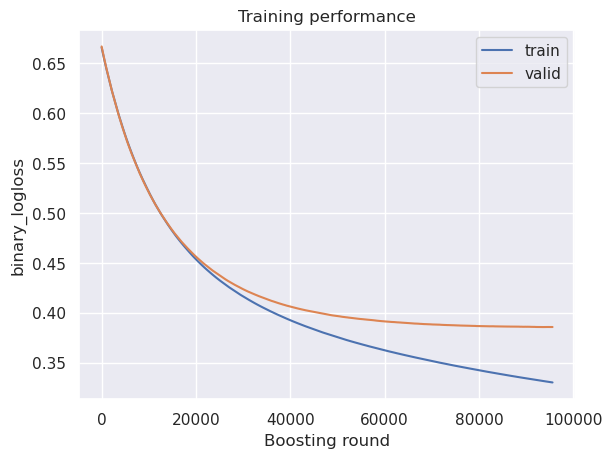

In [33]:
# 学習過程を可視化
# Learning progress

plt.plot(evaluation_results['train'][metric], label='train')
plt.plot(evaluation_results['valid'][metric], label='valid')
plt.ylabel(metric)
plt.xlabel('Boosting round')
plt.title('Training performance')
plt.legend()
plt.show()

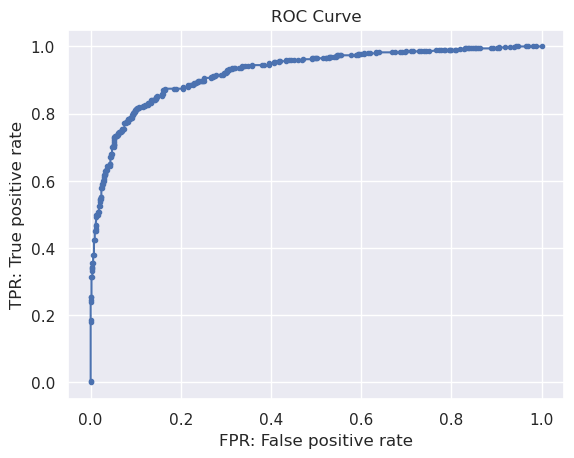

CPU times: user 16.7 s, sys: 0 ns, total: 16.7 s
Wall time: 4.56 s


In [34]:
%%time

# ロック曲線
# Roc Curve

for_verifi = model.predict(X)
true = train['Survived']
fpr, tpr, thresholds = roc_curve(true, for_verifi)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('FPR: False positive rate')
plt.ylabel('TPR: True positive rate')
plt.title('ROC Curve')
plt.show()

In [35]:
# AUC

acc = auc(fpr, tpr)
print("auc : {}".format(acc))

auc : 0.9233055315885341


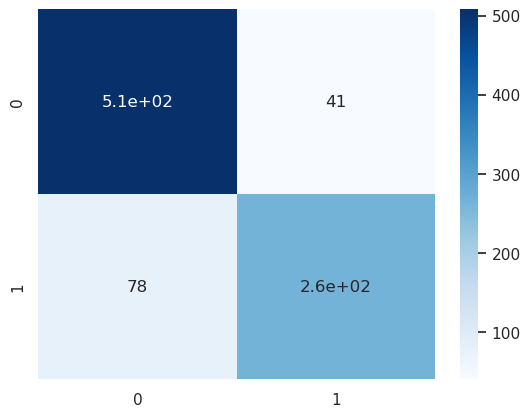

In [36]:
# 混同行列
# Confusion matrix

cm = confusion_matrix(train['Survived'], np.round(for_verifi))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.show()

<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

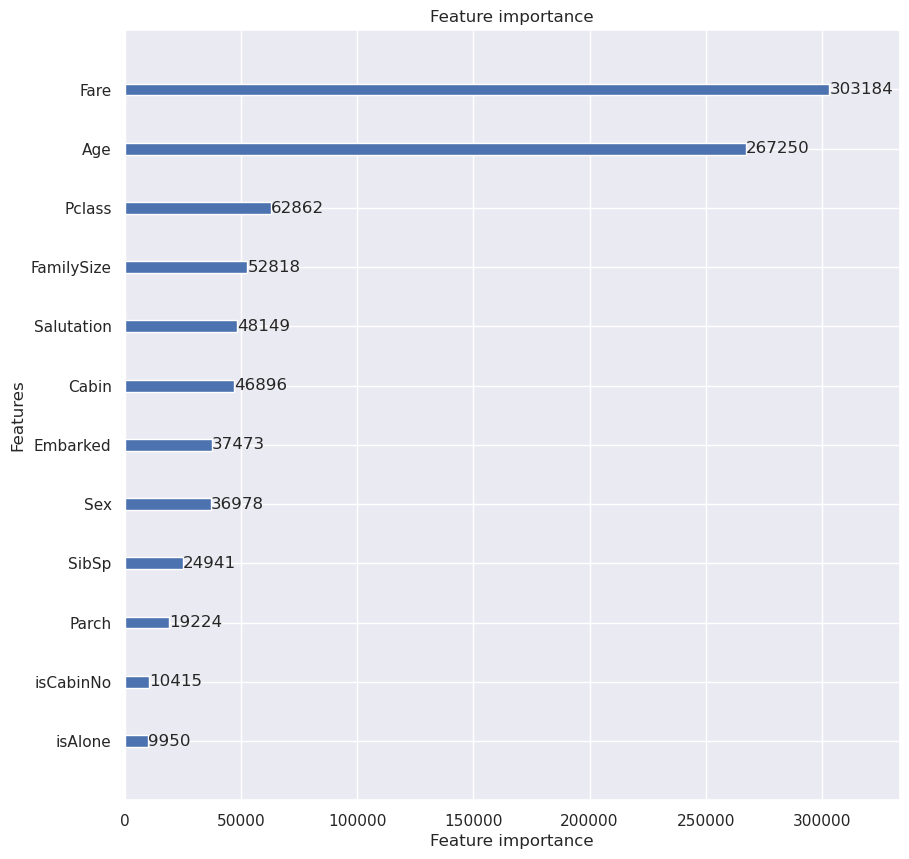

In [37]:
# Feature importance

fig, ax = plt.subplots(figsize=(10, 10))
lgb.plot_importance(model, ax=ax)

# 6. Prediction

In [38]:
%%time

result = model.predict(test[feat_ary])
result

CPU times: user 7.23 s, sys: 0 ns, total: 7.23 s
Wall time: 1.86 s


array([0.1168657 , 0.36136215, 0.06860611, 0.21967444, 0.43586059,
       0.19038831, 0.6245444 , 0.16261136, 0.84508372, 0.04020892,
       0.05886368, 0.1399426 , 0.95353017, 0.05778803, 0.94332647,
       0.61285347, 0.16856136, 0.16307459, 0.51544198, 0.23480148,
       0.18843747, 0.63053656, 0.95258495, 0.2362548 , 0.81950535,
       0.03252194, 0.96165028, 0.17047579, 0.42325942, 0.0583252 ,
       0.06257084, 0.09772119, 0.43008945, 0.44322344, 0.3917779 ,
       0.1925528 , 0.51988395, 0.41663689, 0.1016807 , 0.19843802,
       0.09222367, 0.57550347, 0.07651028, 0.83279635, 0.94161849,
       0.20806258, 0.35082024, 0.07487509, 0.92282557, 0.62861665,
       0.29210744, 0.20339911, 0.78109787, 0.71886789, 0.11712155,
       0.18301481, 0.06913159, 0.2880271 , 0.05614711, 0.97210245,
       0.13722601, 0.21693268, 0.13214519, 0.80840731, 0.57924693,
       0.91220547, 0.85101116, 0.12137859, 0.37953414, 0.71910094,
       0.78870151, 0.07537019, 0.6064504 , 0.55548013, 0.96479

In [39]:
result2 = np.round(result).astype(int)
result2

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

# 7. Make submission file

In [40]:
sample_submission['Survived'] = result2
sample_submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [41]:
sample_submission.to_csv('submission.csv', index=False)